## Preprocessing

In [137]:
import pandas as pd
import glob
from utils import *

In [138]:
dfs = []
for file in glob.glob(f"../results/experiment*solvers*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
df = process_experiments_df(df)
df.head()

,datetime,test case,p,mesh family,fine m,solvers m,coarse m,solver,random rhs,solution warmup steps,...,residual norm,setup metadata,solve times,matrix and DOF map copy times,matrix permute times,solver setup times,rhs copy and permute times,solution permute and copy times,exception,dim
0,2026-02-03T08:25:22.926048+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=T...",False,0,...,2.461959e-10,None,"[1818.7965087890625, 42.148929595947266, 41.26...",[8.393664360046387],[0.026367999613285065],[539.3482666015625],[0.7207679748535156],[1.954975962638855],NaN,2D
1,2026-02-03T08:25:40.282708+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESIVE_L1, torch.float32), bsr_matm...",False,0,...,3.166015e-10,None,"[52.22780990600586, 50.53260803222656, 50.4231...",[34.7243537902832],[0.013567999936640263],[136.02227783203125],[3.2070400714874268],[0.6393280029296875],NaN,2D
2,2026-02-03T08:25:41.178442+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_L1_TRUNC, torch.float32), b...",False,0,...,2.357255e-10,None,"[45.81350326538086, 44.25766372680664, 44.0071...",[8.530303955078125],[0.011648000217974186],[164.90480041503906],[0.4811199903488159],[0.4039359986782074],NaN,2D
3,2026-02-03T08:25:42.199448+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, torch.float3...",False,0,...,1.890703e-10,None,"[51.94255828857422, 51.97564697265625, 51.2618...",[8.527968406677246],[0.023423999547958374],[163.91920471191406],[0.5018560290336609],[0.4713279902935028],NaN,2D
4,2026-02-03T08:25:42.985574+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,CUDSS,False,0,...,2.594297e-13,None,"[4.678783893585205, 2.549760103225708, 2.52313...",[8.45587158203125],[0.012608000077307224],[485.43939208984375],[0.26281601190567017],[0.6216319799423218],NaN,2D


In [139]:
df["best solve time"] = df["solve times"].apply(
    lambda times: min(times) if times else None
)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)

In [140]:
def nice_solver_name(name):
    if name == "CUDSS":
        return "cuDSS"
    elif "Additive" in name:
        return "Additive Schwarz"
    elif "Hybrid" in name:
        return "Hybrid Schwarz"
    else:  # AmgX
        config = name.split("AMGX(")[1].split(",")[0]
        return f"AmgX ({config})"


df["solver"] = df["solver"].apply(nice_solver_name)

## Is the data complete?

In [141]:
assert df["solve times"].isna().sum() == (~df["exception"].isna()).sum()

In [142]:
manually_verified_to_fail = pd.read_csv("../results/manually_verified_to_fail.csv")
manually_verified_to_fail["solver"] = manually_verified_to_fail["solver"].apply(
    nice_solver_name
)
manually_verified_to_fail

,test case,p,fine m,solver,exception
0,continuous coefficient 2D,4,S10,AmgX (L1_TRUNC),Thrust failure: parallel_for: failed to synchr...
1,continuous coefficient 3D,1,S7,cuDSS,RuntimeError: CUDA error: an illegal memory ac...


In [143]:
problems = df[["test case", "p", "fine m"]].drop_duplicates().reset_index(drop=True)
solvers = df["solver"].unique()

complete = True
for test_case, p, fine_m in problems.itertuples(index=False):
    for solver in solvers:
        df_subset = df[
            (df["test case"] == test_case)
            & (df["p"] == p)
            & (df["fine m"] == fine_m)
            & (df["solver"] == solver)
        ]
        manually_subset = manually_verified_to_fail[
            (manually_verified_to_fail["test case"] == test_case)
            & (manually_verified_to_fail["p"] == p)
            & (manually_verified_to_fail["fine m"] == fine_m)
            & (manually_verified_to_fail["solver"] == solver)
        ]
        if df_subset.empty and manually_subset.empty:
            complete = False
            print(f"No data for {test_case}, p={p}, fine m={fine_m}, solver={solver}")

if complete:
    print(
        "All combinations of test case, p, fine m, and solver are covered in the data!"
    )

All combinations of test case, p, fine m, and solver are covered in the data!


## Throughput vs polynomial degree

In [144]:
NUM_LARGEST_TO_CONSIDER_IN_TPUT = 3


def get_m(mesh):
    return int(mesh[1:])


large_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if get_m(problem["fine m"]) + NUM_LARGEST_TO_CONSIDER_IN_TPUT
        > problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
    ]
)

df_large = df.merge(
    large_problems, on=["test case", "p", "fine m"], how="inner"
)

In [145]:
tputs = df_large.pivot_table(
    values="DoF/s",
    index=["test case", "p"],
    columns=["solver"],
    aggfunc="max",
)
tputs

KeyError: 'DoF/s'

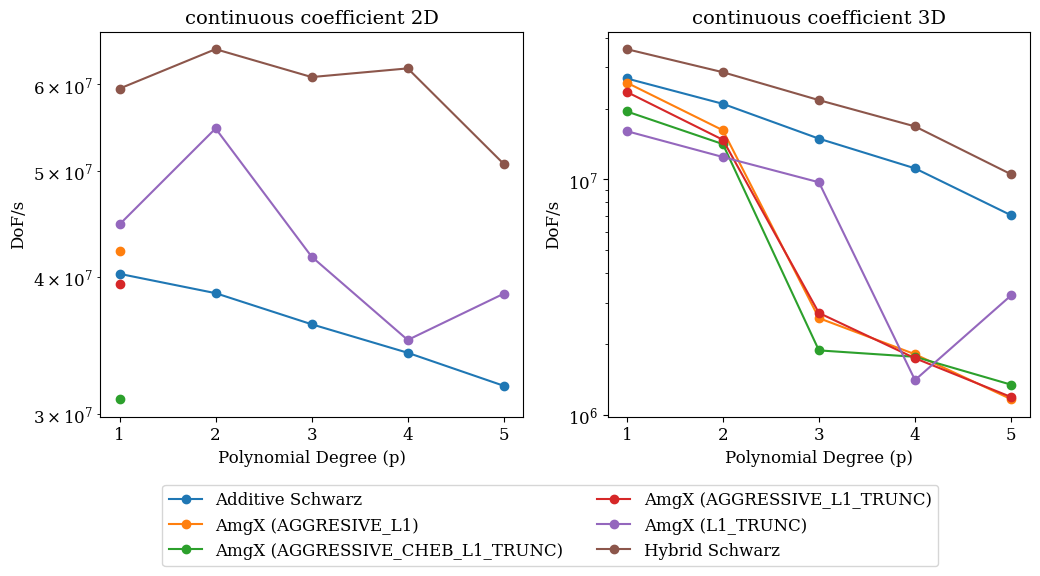

In [ ]:
fig, axes = plt.subplots(1, len(tputs.index.levels[0]), figsize=(12, 5))
for i, test_case in enumerate(tputs.index.levels[0]):
    ax = axes[i]
    data = tputs.loc[test_case]
    for solver in data.columns:
        if data[solver].isna().all():
            continue
        if solver == "cuDSS":
            continue
        ax.plot(data.index, data[solver], marker="o", label=solver if i == 0 else None)
    ax.set_title(test_case)
    ax.set_xlabel("Polynomial Degree (p)")
    ax.set_ylabel("DoF/s")
    ax.set_yscale("log")
fig.legend(bbox_to_anchor=(0.5, -0.01), loc="upper center", ncol=2)

## Largest managable problems

In [81]:
def matrix_size(row):
    nnz = row["matrix nnz"]
    n = row["DoFs"]
    return nnz * (8 + 4) + (n + 1) * 4


df["matrix size (bytes)"] = df.apply(matrix_size, axis=1)

df[df["exception"].isna()].pivot_table(
    index=["test case"],
    columns="solver",
    values="matrix size (bytes)",
    aggfunc="max",
).map(lambda x: f"{x:,}" if pd.notna(x) else "N/A")

solver,Additive Schwarz,AmgX (AGGRESIVE_L1),AmgX (AGGRESSIVE_CHEB_L1_TRUNC),AmgX (AGGRESSIVE_L1_TRUNC),AmgX (L1_TRUNC),Hybrid Schwarz,cuDSS
test case,,,,,,,
continuous coefficient 2D,"22,764,011,524","14,896,398,340","14,896,398,340","14,896,398,340","14,896,398,340","22,764,011,524","11,131,330,564"
continuous coefficient 3D,"14,297,579,524","14,297,579,524","14,297,579,524","14,297,579,524","9,441,116,164","14,297,579,524","4,514,119,684"


In [3]:
problems = (
    df[["test case", "p", "mesh family", "fine m"]]
    .drop_duplicates()
    .sort_values(by=["test case", "p", "mesh family", "fine m"])
    .reset_index(drop=True)
)

problems = problems[~problems["mesh family"].str.contains("unstructured")]

problems

,test case,p,mesh family,fine m
0,continuous coefficient 2D,1,"uniform(2D,10)",S10
1,continuous coefficient 2D,1,"uniform(2D,11)",S11
2,continuous coefficient 2D,1,"uniform(2D,12)",S12
3,continuous coefficient 2D,1,"uniform(2D,8)",S8
4,continuous coefficient 2D,1,"uniform(2D,9)",S9
5,continuous coefficient 2D,3,"uniform(2D,10)",S10
6,continuous coefficient 2D,3,"uniform(2D,6)",S6
7,continuous coefficient 2D,3,"uniform(2D,7)",S7
8,continuous coefficient 2D,3,"uniform(2D,8)",S8
9,continuous coefficient 2D,3,"uniform(2D,9)",S9


In [24]:
def get_m(mesh):
    return int(mesh[1:])


largest_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
        == get_m(problem["fine m"])
    ]
)

largest_problems

,test case,p,mesh family,fine m
2,continuous coefficient 2D,1,"uniform(2D,12)",S12
5,continuous coefficient 2D,3,"uniform(2D,10)",S10
14,continuous coefficient 2D,5,"uniform(2D,9)",S9
19,continuous coefficient 3D,1,"uniform(3D,7)",S7
24,continuous coefficient 3D,2,"uniform(3D,6)",S6
29,continuous coefficient 3D,3,"uniform(3D,5)",S5
33,continuous coefficient 3D,4,"uniform(3D,4)",S4


In [4]:
def process_experiments_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["solve time"] = df["solve times"].apply(
        lambda times: (
            min(times) if times is not None and len(times) > 0 else float("inf")
        )
    )

    df = df[df.solver.str.contains("CG")].copy()

    summary = df.pivot_table(
        index=["solver"],
        columns=["coarse m", "solvers m"],
        values="solve time",
        aggfunc="min",
    )
    summary["best"] = summary.min(axis=1)

    best_amgx_key = summary["best"][summary.index.str.contains("AMGX")].idxmin()
    best_amgx_variant = best_amgx_key[8:].split(",")[0]
    best_amgx_time = summary["best"][best_amgx_key]

    best_additive_key = summary["best"][
        summary.index.str.contains("AdditiveSchwarz")
    ].idxmin()
    best_additive_time = summary["best"][best_additive_key]
    best_additive_by_meshes = summary[
        summary.index.str.contains("AdditiveSchwarz")
    ].min()
    best_additive_meshing = best_additive_by_meshes.idxmin()

    best_hybrid_key = summary["best"][
        summary.index.str.contains("HybridSchwarz")
    ].idxmin()
    best_hybrid_time = summary["best"][best_hybrid_key]
    best_hybrid_by_meshes = summary[summary.index.str.contains("HybridSchwarz")].min()
    best_hybrid_meshing = best_hybrid_by_meshes.idxmin()

    # parallel_mask = [b == (fine_m, "S") for a, b in best_by_meshes.index]
    # best_parallel_meshing = best_by_meshes[parallel_mask].idxmin()
    # best_parallel_time = best_by_meshes[best_parallel_meshing]
    # best_parallel_precision = best_by_meshes_prec[best_parallel_meshing]

    # classical_mask = [a == b for a, b in best_by_meshes.index]
    # best_classical_meshing = best_by_meshes[classical_mask].idxmin()
    # best_classical_time = best_by_meshes[best_classical_meshing]
    # best_classical_precision = best_by_meshes_prec[best_classical_meshing]

    return pd.Series(
        {
            "best_amgx_variant": best_amgx_variant,
            "best_amgx_time": best_amgx_time,
            "best_additive_time": best_additive_time,
            "best_additive_meshing": best_additive_meshing,
            "best_hybrid_time": best_hybrid_time,
            "best_hybrid_meshing": best_hybrid_meshing,
            # "best_asm_time": best_asm_time,
            # "best_asm_precision": best_asm_precision,
            # "best_parallel_meshing": best_parallel_meshing,
            # "best_parallel_time": best_parallel_time,
            # "best_parallel_precision": best_parallel_precision,
            # "best_classical_meshing": best_classical_meshing,
            # "best_classical_time": best_classical_time,
            # "best_classical_precision": best_classical_precision,
        }
    )

In [6]:
def get_dofs(d, fine_m, p):
    element_dofs = {
        # (d, p)
        (2, 1): 3,
        (2, 3): 10,
        (2, 5): 21,
        (3, 1): 4,
        (3, 2): 10,
        (3, 3): 20,
        (3, 4): 35,
    }
    return 2 ** (d * fine_m) * (2 if d == 2 else 6) * element_dofs[(d, p)]

In [7]:
def get_problem_summary(problem):
    test_case = problem["test case"]
    p = problem["p"]
    mesh_family = problem["mesh family"]
    fine_m = problem["fine m"]

    data = df[
        (df["test case"] == test_case)
        & (df["p"] == p)
        & (df["fine m"] == fine_m)
        & (df["mesh family"] == mesh_family)
    ]
    if data.empty:
        return pd.Series()

    summary = process_experiments_df(data)
    d = int(test_case[-2])
    summary["d"] = d
    summary["mesh family"] = mesh_family
    summary["m"] = fine_m
    summary["p"] = p
    summary["DoFs"] = get_dofs(d, int(fine_m[1:]), p) if fine_m != "F" else None

    return summary

In [25]:
speedup_table = pd.DataFrame(
    get_problem_summary(problem) for _, problem in largest_problems.iterrows()
)
speedup_table

,best_amgx_variant,best_amgx_time,best_additive_time,best_additive_meshing,best_hybrid_time,best_hybrid_meshing,d,mesh family,m,p,DoFs
0,L1_TRUNC,2252.932373,2499.763428,"(C10, S11)",1824.602905,"(C11, C12)",2,"uniform(2D,12)",S12,1,100663296
1,L1_TRUNC,1507.047485,1737.356812,"(S9, S9)",1032.556396,"(C10, C10)",2,"uniform(2D,10)",S10,3,20971520
2,L1_TRUNC,1425.344849,1730.400879,"(S9, S9)",1084.872559,"(C9, C9)",2,"uniform(2D,9)",S9,5,11010048
3,AGGRESIVE_L1,1952.959351,1874.077026,"(C6, C7)",1407.375854,"(C6, C7)",3,"uniform(3D,7)",S7,1,50331648
4,AGGRESIVE_L1,1943.803833,1501.115112,"(C5, C6)",1101.878052,"(C5, C6)",3,"uniform(3D,6)",S6,2,15728640
5,L1_TRUNC,1212.115356,791.230652,"(C5, C5)",542.874451,"(C5, C5)",3,"uniform(3D,5)",S5,3,3932160
6,AGGRESIVE_L1,1899.891602,397.857361,"(C4, C4)",265.750885,"(C4, C4)",3,"uniform(3D,4)",S4,4,860160


In [26]:
# assert (speedup_table["best_asm_precision"] == "fp32+fp16").all()
# assert (speedup_table["best_parallel_precision"] == "fp32+fp16").all()
# assert (speedup_table["best_classical_precision"] == "fp32+fp16").all()

In [27]:
tab = pd.DataFrame()
tab[["$d$", "$p$"]] = speedup_table[["d", "p"]]
tab["$\\mathcal{T}_h$"] = speedup_table["m"].apply(lambda m: f"${format_mesh(m)}$")
tab["DoFs"] = speedup_table["DoFs"].apply(lambda n: f"{n / 1_000_000:.1f}\\,{{M}}")

amgx_best = "best AmgX configuration found"
additive_best = "best AdditiveSchwarz variant"
hybrid_best = "best HybridSchwarz variant"

tab[(amgx_best, "name")] = speedup_table["best_amgx_variant"].map(
    lambda v: f"\\verb|{v.replace('AGGRESIVE', 'AGGRESSIVE')}|"
)
tab[(amgx_best, "time")] = speedup_table["best_amgx_time"] / 1000
tab[(additive_best, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_additive_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab[(additive_best, "$\\mathcal{T}_H$")] = speedup_table["best_additive_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab[(additive_best, "time")] = speedup_table["best_additive_time"] / 1000
tab[(additive_best, "speedup")] = (
    tab[(amgx_best, "time")] / tab[(additive_best, "time")]
)

tab[(hybrid_best, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_hybrid_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab[(hybrid_best, "$\\mathcal{T}_H$")] = speedup_table["best_hybrid_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab[(hybrid_best, "time")] = speedup_table["best_hybrid_time"] / 1000
tab[(hybrid_best, "speedup")] = tab[(amgx_best, "time")] / tab[(hybrid_best, "time")]

tab.set_index(["$d$", "$p$", "$\\mathcal{T}_h$", "DoFs"], inplace=True)


def time_latex(t: float):
    return f"{t:.6f}\\, \\si{{\\second}}"


def speedup_latex(s: float):
    return f"{s:.6f} \\,\\(\\times\\)"


tab[(amgx_best, "time")] = tab[(amgx_best, "time")].apply(time_latex)
tab[(additive_best, "time")] = tab[(additive_best, "time")].apply(time_latex)
tab[(additive_best, "speedup")] = tab[(additive_best, "speedup")].apply(speedup_latex)
tab[(hybrid_best, "time")] = tab[(hybrid_best, "time")].apply(time_latex)
tab[(hybrid_best, "speedup")] = tab[(hybrid_best, "speedup")].apply(speedup_latex)

tab.columns = pd.MultiIndex.from_tuples(tab.columns)
tab.rename(columns=lambda c: f"{{{c}}}", inplace=True)
tab

{best AmgX configuration found}  \
                                                               {name}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                         
2   1   $\mathcal{S}_{12}$ 100.7\,{M}                 \verb|L1_TRUNC|   
    3   $\mathcal{S}_{10}$ 21.0\,{M}                  \verb|L1_TRUNC|   
    5   $\mathcal{S}_{9}$  11.0\,{M}                  \verb|L1_TRUNC|   
3   1   $\mathcal{S}_{7}$  50.3\,{M}             \verb|AGGRESSIVE_L1|   
    2   $\mathcal{S}_{6}$  15.7\,{M}             \verb|AGGRESSIVE_L1|   
    3   $\mathcal{S}_{5}$  3.9\,{M}                   \verb|L1_TRUNC|   
    4   $\mathcal{S}_{4}$  0.9\,{M}              \verb|AGGRESSIVE_L1|   

                                                                \
                                                        {time}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                  
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  2.252932\, \si{\second}   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   1.507047\, \si{\second}   
    5   $\mathcal{S}_{9}$  11.0\,{M}   1.425345\, \si{\second}   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.952959\, \si{\second}   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.943804\, \si{\second}   
    3   $\mathcal{S}_{5}$  3.9\,{M}    1.212115\, \si{\second}   
    4   $\mathcal{S}_{4}$  0.9\,{M}    1.899892\, \si{\second}   

                                      {best AdditiveSchwarz variant}  \
                                         {$\mathcal{T}_\mathcal{H}$}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                        
2   1   $\mathcal{S}_{12}$ 100.7\,{M}             $\mathcal{C}_{10}$   
    3   $\mathcal{S}_{10}$ 21.0\,{M}               $\mathcal{S}_{9}$   
    5   $\mathcal{S}_{9}$  11.0\,{M}               $\mathcal{S}_{9}$   
3   1   $\mathcal{S}_{7}$  50.3\,{M}               $\mathcal{C}_{6}$   
    2   $\mathcal{S}_{6}$  15.7\,{M}               $\mathcal{C}_{5}$   
    3   $\mathcal{S}_{5}$  3.9\,{M}                $\mathcal{C}_{5}$   
    4   $\mathcal{S}_{4}$  0.9\,{M}                $\mathcal{C}_{4}$   

                                                           \
                                        {$\mathcal{T}_H$}   
$d$ $p$ $\mathcal{T}_h$    DoFs                             
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  $\mathcal{S}_{11}$   
    3   $\mathcal{S}_{10}$ 21.0\,{M}    $\mathcal{S}_{9}$   
    5   $\mathcal{S}_{9}$  11.0\,{M}    $\mathcal{S}_{9}$   
3   1   $\mathcal{S}_{7}$  50.3\,{M}    $\mathcal{C}_{7}$   
    2   $\mathcal{S}_{6}$  15.7\,{M}    $\mathcal{C}_{6}$   
    3   $\mathcal{S}_{5}$  3.9\,{M}     $\mathcal{C}_{5}$   
    4   $\mathcal{S}_{4}$  0.9\,{M}     $\mathcal{C}_{4}$   

                                                                \
                                                        {time}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                  
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  2.499763\, \si{\second}   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   1.737357\, \si{\second}   
    5   $\mathcal{S}_{9}$  11.0\,{M}   1.730401\, \si{\second}   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.874077\, \si{\second}   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.501115\, \si{\second}   
    3   $\mathcal{S}_{5}$  3.9\,{M}    0.791231\, \si{\second}   
    4   $\mathcal{S}_{4}$  0.9\,{M}    0.397857\, \si{\second}   

                                                              \
                                                   {speedup}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  0.901258 \,\(\times\)   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   0.867437 \,\(\times\)   
    5   $\mathcal{S}_{9}$  11.0\,{M}   0.823708 \,\(\times\)   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.042091 \,\(\times\)   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.294907 \,\(\times\)   
    3   $\mathcal{S}_{5}$  3.9\,{M}    1.531937 \,\(\times\)   
    4   $\mathcal{S}_{4}$  0.9\,{M}    4.775308 \,\(\times\)   

            

In [28]:
time_col = "S[table-format=1.3\\,s, round-mode=places, round-precision=3]"
speedup_col = "S[table-format=1.3, round-mode=places, round-precision=3]"
dofs_col = "S[table-format=2.1\\,M]"
tab_latex = tab.style.to_latex(
    hrules=True,
    multirow_align="t",
    multicol_align="c",
    column_format=f"rrc{dofs_col}|l{time_col}|cc{time_col}{speedup_col}|cc{time_col}{speedup_col}",
)

In [29]:
custom_header = r"""
 &  &  &  & \multicolumn{2}{c|}{{best AmgX configuration found}} & \multicolumn{4}{c|}{{best additive variant considered}} & \multicolumn{4}{c}{{best hybrid variant considered}} \\
$d$ & $p$ & $\mathcal{T}_h$ & {DoFs} & {name} & {time} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} \\
"""

before_header = tab_latex.split("\\toprule")[0] + "\\toprule\n"
after_header = "\n\\midrule\n" + tab_latex.split("\\midrule")[1]
hacked_latex = before_header + custom_header + after_header
hacked_latex = hacked_latex.replace(
    "\\multirow[t]{3}{*}{3}", "\\midrule\n\\multirow[t]{3}{*}{3}"
)

In [30]:
with open("../docs/tables/experiment_speedups.tex", "w") as f:
    f.write(hacked_latex)

In [31]:
tab2 = pd.DataFrame()
tab2[["$d$", "$p$"]] = speedup_table[["d", "p"]]
tab2["$\\mathcal{T}_h$"] = speedup_table["m"].apply(
    lambda m: f"${format_mesh((m, 'S'))}$"
)
tab2["DoFs"] = speedup_table["DoFs"].apply(lambda n: f"{n / 1_000_000:.1f}\\,{{M}}")

asm_parallel = "best ASM variant with $\\mathcal{T}_H = \\mathcal{T}_h$"
asm_classical = "best ASM variant with $\\mathcal{T}_H = \\mathcal{T}_\\mathcal{H}$"

tab2[(asm_classical, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_classical_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab2[(asm_classical, "$\\mathcal{T}_H$")] = speedup_table["best_classical_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab2[(asm_classical, "time")] = speedup_table["best_classical_time"] / 1000
tab2[(asm_classical, "speedup")] = (
    speedup_table["best_amgx_time"] / tab2[(asm_classical, "time")] / 1000
)

tab2[(asm_parallel, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_parallel_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab2[(asm_parallel, "$\\mathcal{T}_H$")] = speedup_table["best_parallel_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab2[(asm_parallel, "time")] = speedup_table["best_parallel_time"] / 1000
tab2[(asm_parallel, "speedup")] = (
    speedup_table["best_amgx_time"] / tab2[(asm_parallel, "time")] / 1000
)

tab2.set_index(["$d$", "$p$", "$\\mathcal{T}_h$", "DoFs"], inplace=True)

tab2[(asm_classical, "time")] = tab2[(asm_classical, "time")].apply(time_latex)
tab2[(asm_parallel, "time")] = tab2[(asm_parallel, "time")].apply(time_latex)
tab2[(asm_classical, "speedup")] = tab2[(asm_classical, "speedup")].apply(speedup_latex)
tab2[(asm_parallel, "speedup")] = tab2[(asm_parallel, "speedup")].apply(speedup_latex)

tab2.columns = pd.MultiIndex.from_tuples(tab2.columns)
tab2.rename(columns=lambda c: f"{{{c}}}", inplace=True)
tab2

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'tuple'

In [ ]:
tab_latex = tab2.style.to_latex(
    hrules=True,
    multirow_align="t",
    multicol_align="c",
    column_format=f"rrc{dofs_col}|cc{time_col}{speedup_col}|cc{time_col}{speedup_col}",
)

In [ ]:
custom_header = r"""
 &  &  & & \multicolumn{4}{c|}{{best ASM variant with $\mathcal{T}_H = \mathcal{T}_\mathcal{H}$}} & \multicolumn{4}{c}{{best ASM variant with $\mathcal{T}_H = \mathcal{T}_h$}} \\
$d$ & $p$ & $\mathcal{T}_h$ & {DoFs} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} \\
"""
before_header = tab_latex.split("\\toprule")[0] + "\\toprule\n"
after_header = "\n\\midrule\n" + tab_latex.split("\\midrule")[1]
hacked_latex = before_header + custom_header + after_header
hacked_latex = hacked_latex.replace(
    "\\multirow[t]{3}{*}{3}", "\\midrule\n\\multirow[t]{3}{*}{3}"
)

In [ ]:
with open("../docs/tables/experiment_speedups_2.tex", "w") as f:
    f.write(hacked_latex)